In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import re

In [4]:
df = pd.read_csv('vcrelax_physical_info.csv')
df

,File,a (Å),c (Å),c/a Ratio,Band Gap (eV)
0,zno_vcrelax_hubbard_10.00_7.50.out,3.267506,5.222977,1.598460,3.201
1,zno_vcrelax_hubbard_10.50_7.50.out,3.268576,5.223509,1.598099,3.225
2,zno_vcrelax_hubbard_11.00_7.50.out,3.269612,5.224257,1.597822,3.247
3,zno_vcrelax_hubbard_11.50_7.50.out,3.270629,5.224876,1.597514,3.269
4,zno_vcrelax_hubbard_12.00_7.50.out,3.271614,5.225553,1.597240,3.288
5,zno_vcrelax_hubbard_9.50_8.00.out,3.264846,5.218569,1.598412,3.310
6,zno_vcrelax_hubbard_10.00_8.00.out,3.265924,5.219244,1.598091,3.336
7,zno_vcrelax_hubbard_10.50_8.00.out,3.266982,5.219911,1.597778,3.360
8,zno_vcrelax_hubbard_8.50_8.50.out,3.267458,5.226625,1.599600,3.368
9,zno_vcrelax_hubbard_11.00_8.00.out,3.268017,5.220563,1.597471,3.383


In [ ]:
# Extraindo os valores de U_zn e U_o da coluna 'File'
df['U_Zn'] = df['File'].str.extract(r'_([\d.]+)_')[0].astype(float)
df['U_O'] = df['File'].str.extract(r'_([\d.]+)_([\d.]+)\.out')[1].astype(float)


df

,File,a (Å),c (Å),c/a Ratio,Band Gap (eV),U_Zn,U_O
0,zno_vcrelax_hubbard_10.00_7.50.out,3.267506,5.222977,1.598460,3.201,10.0,7.5
1,zno_vcrelax_hubbard_10.50_7.50.out,3.268576,5.223509,1.598099,3.225,10.5,7.5
2,zno_vcrelax_hubbard_11.00_7.50.out,3.269612,5.224257,1.597822,3.247,11.0,7.5
3,zno_vcrelax_hubbard_11.50_7.50.out,3.270629,5.224876,1.597514,3.269,11.5,7.5
4,zno_vcrelax_hubbard_12.00_7.50.out,3.271614,5.225553,1.597240,3.288,12.0,7.5
5,zno_vcrelax_hubbard_9.50_8.00.out,3.264846,5.218569,1.598412,3.310,9.5,8.0
6,zno_vcrelax_hubbard_10.00_8.00.out,3.265924,5.219244,1.598091,3.336,10.0,8.0
7,zno_vcrelax_hubbard_10.50_8.00.out,3.266982,5.219911,1.597778,3.360,10.5,8.0
8,zno_vcrelax_hubbard_8.50_8.50.out,3.267458,5.226625,1.599600,3.368,8.5,8.5
9,zno_vcrelax_hubbard_11.00_8.00.out,3.268017,5.220563,1.597471,3.383,11.0,8.0


In [40]:
a_exper = 3.2427
c_exper = 5.1948
ratio_ca_exper = 1.602

df['delta_a'] = df['a (Å)'] - a_exper 
df['delta_c'] = df['c (Å)'] - c_exper
df['delta_ratio_ca'] = df['c/a Ratio'] - ratio_ca_exper
df['delta_a (%)'] = (df['delta_a'] / df['a (Å)']) * 100
df['delta_c (%)'] = (df['delta_c'] / df['c (Å)']) * 100
df['delta_ratio_ca (%)'] = (df['delta_ratio_ca'] / df['c/a Ratio']) * 100
df

,File,a (Å),c (Å),c/a Ratio,Band Gap (eV),U_Zn,U_O,delta_a,delta_c,delta_ratio_ca,delta_a (%),delta_c (%),delta_ratio_ca (%)
0,zno_vcrelax_hubbard_10.00_7.50.out,3.267506,5.222977,1.598460,3.201,10.0,7.5,0.024806,0.028177,-0.003540,0.759180,0.539490,-0.221475
1,zno_vcrelax_hubbard_10.50_7.50.out,3.268576,5.223509,1.598099,3.225,10.5,7.5,0.025876,0.028709,-0.003901,0.791669,0.549606,-0.244098
2,zno_vcrelax_hubbard_11.00_7.50.out,3.269612,5.224257,1.597822,3.247,11.0,7.5,0.026912,0.029457,-0.004178,0.823093,0.563842,-0.261507
3,zno_vcrelax_hubbard_11.50_7.50.out,3.270629,5.224876,1.597514,3.269,11.5,7.5,0.027929,0.030076,-0.004486,0.853943,0.575623,-0.280821
4,zno_vcrelax_hubbard_12.00_7.50.out,3.271614,5.225553,1.597240,3.288,12.0,7.5,0.028914,0.030753,-0.004760,0.883789,0.588519,-0.298007
5,zno_vcrelax_hubbard_9.50_8.00.out,3.264846,5.218569,1.598412,3.310,9.5,8.0,0.022146,0.023769,-0.003588,0.678329,0.455461,-0.224494
6,zno_vcrelax_hubbard_10.00_8.00.out,3.265924,5.219244,1.598091,3.336,10.0,8.0,0.023224,0.024444,-0.003909,0.711104,0.468338,-0.244609
7,zno_vcrelax_hubbard_10.50_8.00.out,3.266982,5.219911,1.597778,3.360,10.5,8.0,0.024282,0.025111,-0.004222,0.743254,0.481054,-0.264267
8,zno_vcrelax_hubbard_8.50_8.50.out,3.267458,5.226625,1.599600,3.368,8.5,8.5,0.024758,0.031825,-0.002400,0.757702,0.608905,-0.150038
9,zno_vcrelax_hubbard_11.00_8.00.out,3.268017,5.220563,1.597471,3.383,11.0,8.0,0.025317,0.025763,-0.004529,0.774685,0.493499,-0.283486


In [37]:
print("Avaliando parâmetros de rede experimentais.")

print('Melhor resultado de a:')
display(df.loc[ df['delta_a'].idxmin() ])
print('Melhor resultado de c')
display(df.loc[ df['delta_c'].idxmin() ])
print('Melhor resultado da razão c/a:')
display(df.loc[ df['delta_ratio_ca'].idxmin() ])



Avaliando parâmetros de rede experimentais.
Melhor resultado de a:


File              zno_vcrelax_hubbard_9.50_8.00.out
a (Å)                                      3.264846
c (Å)                                      5.218569
c/a Ratio                                  1.598412
Band Gap (eV)                                  3.31
U_Zn                                            9.5
U_O                                             8.0
delta_a                                    0.022146
delta_c                                    0.023769
delta_ratio_ca                            -0.003588
Name: 5, dtype: object

Melhor resultado de c


File              zno_vcrelax_hubbard_9.50_8.00.out
a (Å)                                      3.264846
c (Å)                                      5.218569
c/a Ratio                                  1.598412
Band Gap (eV)                                  3.31
U_Zn                                            9.5
U_O                                             8.0
delta_a                                    0.022146
delta_c                                    0.023769
delta_ratio_ca                            -0.003588
Name: 5, dtype: object

Melhor resultado da razão c/a:


File              zno_vcrelax_hubbard_11.50_8.00.out
a (Å)                                       3.269011
c (Å)                                       5.221312
c/a Ratio                                   1.597215
Band Gap (eV)                                    3.4
U_Zn                                            11.5
U_O                                              8.0
delta_a                                     0.026311
delta_c                                     0.026512
delta_ratio_ca                             -0.004785
Name: 10, dtype: object

Experimental Values, Table 3 from: 

Goh, E. S., Mah, J. W., & Yoon, T. L. (2017). Effects of Hubbard term correction on the structural parameters and electronic properties of wurtzite ZnO. Computational Materials Science, 138, 111–116. https://doi.org/10.1016/j.commatsci.2017.06.032

---

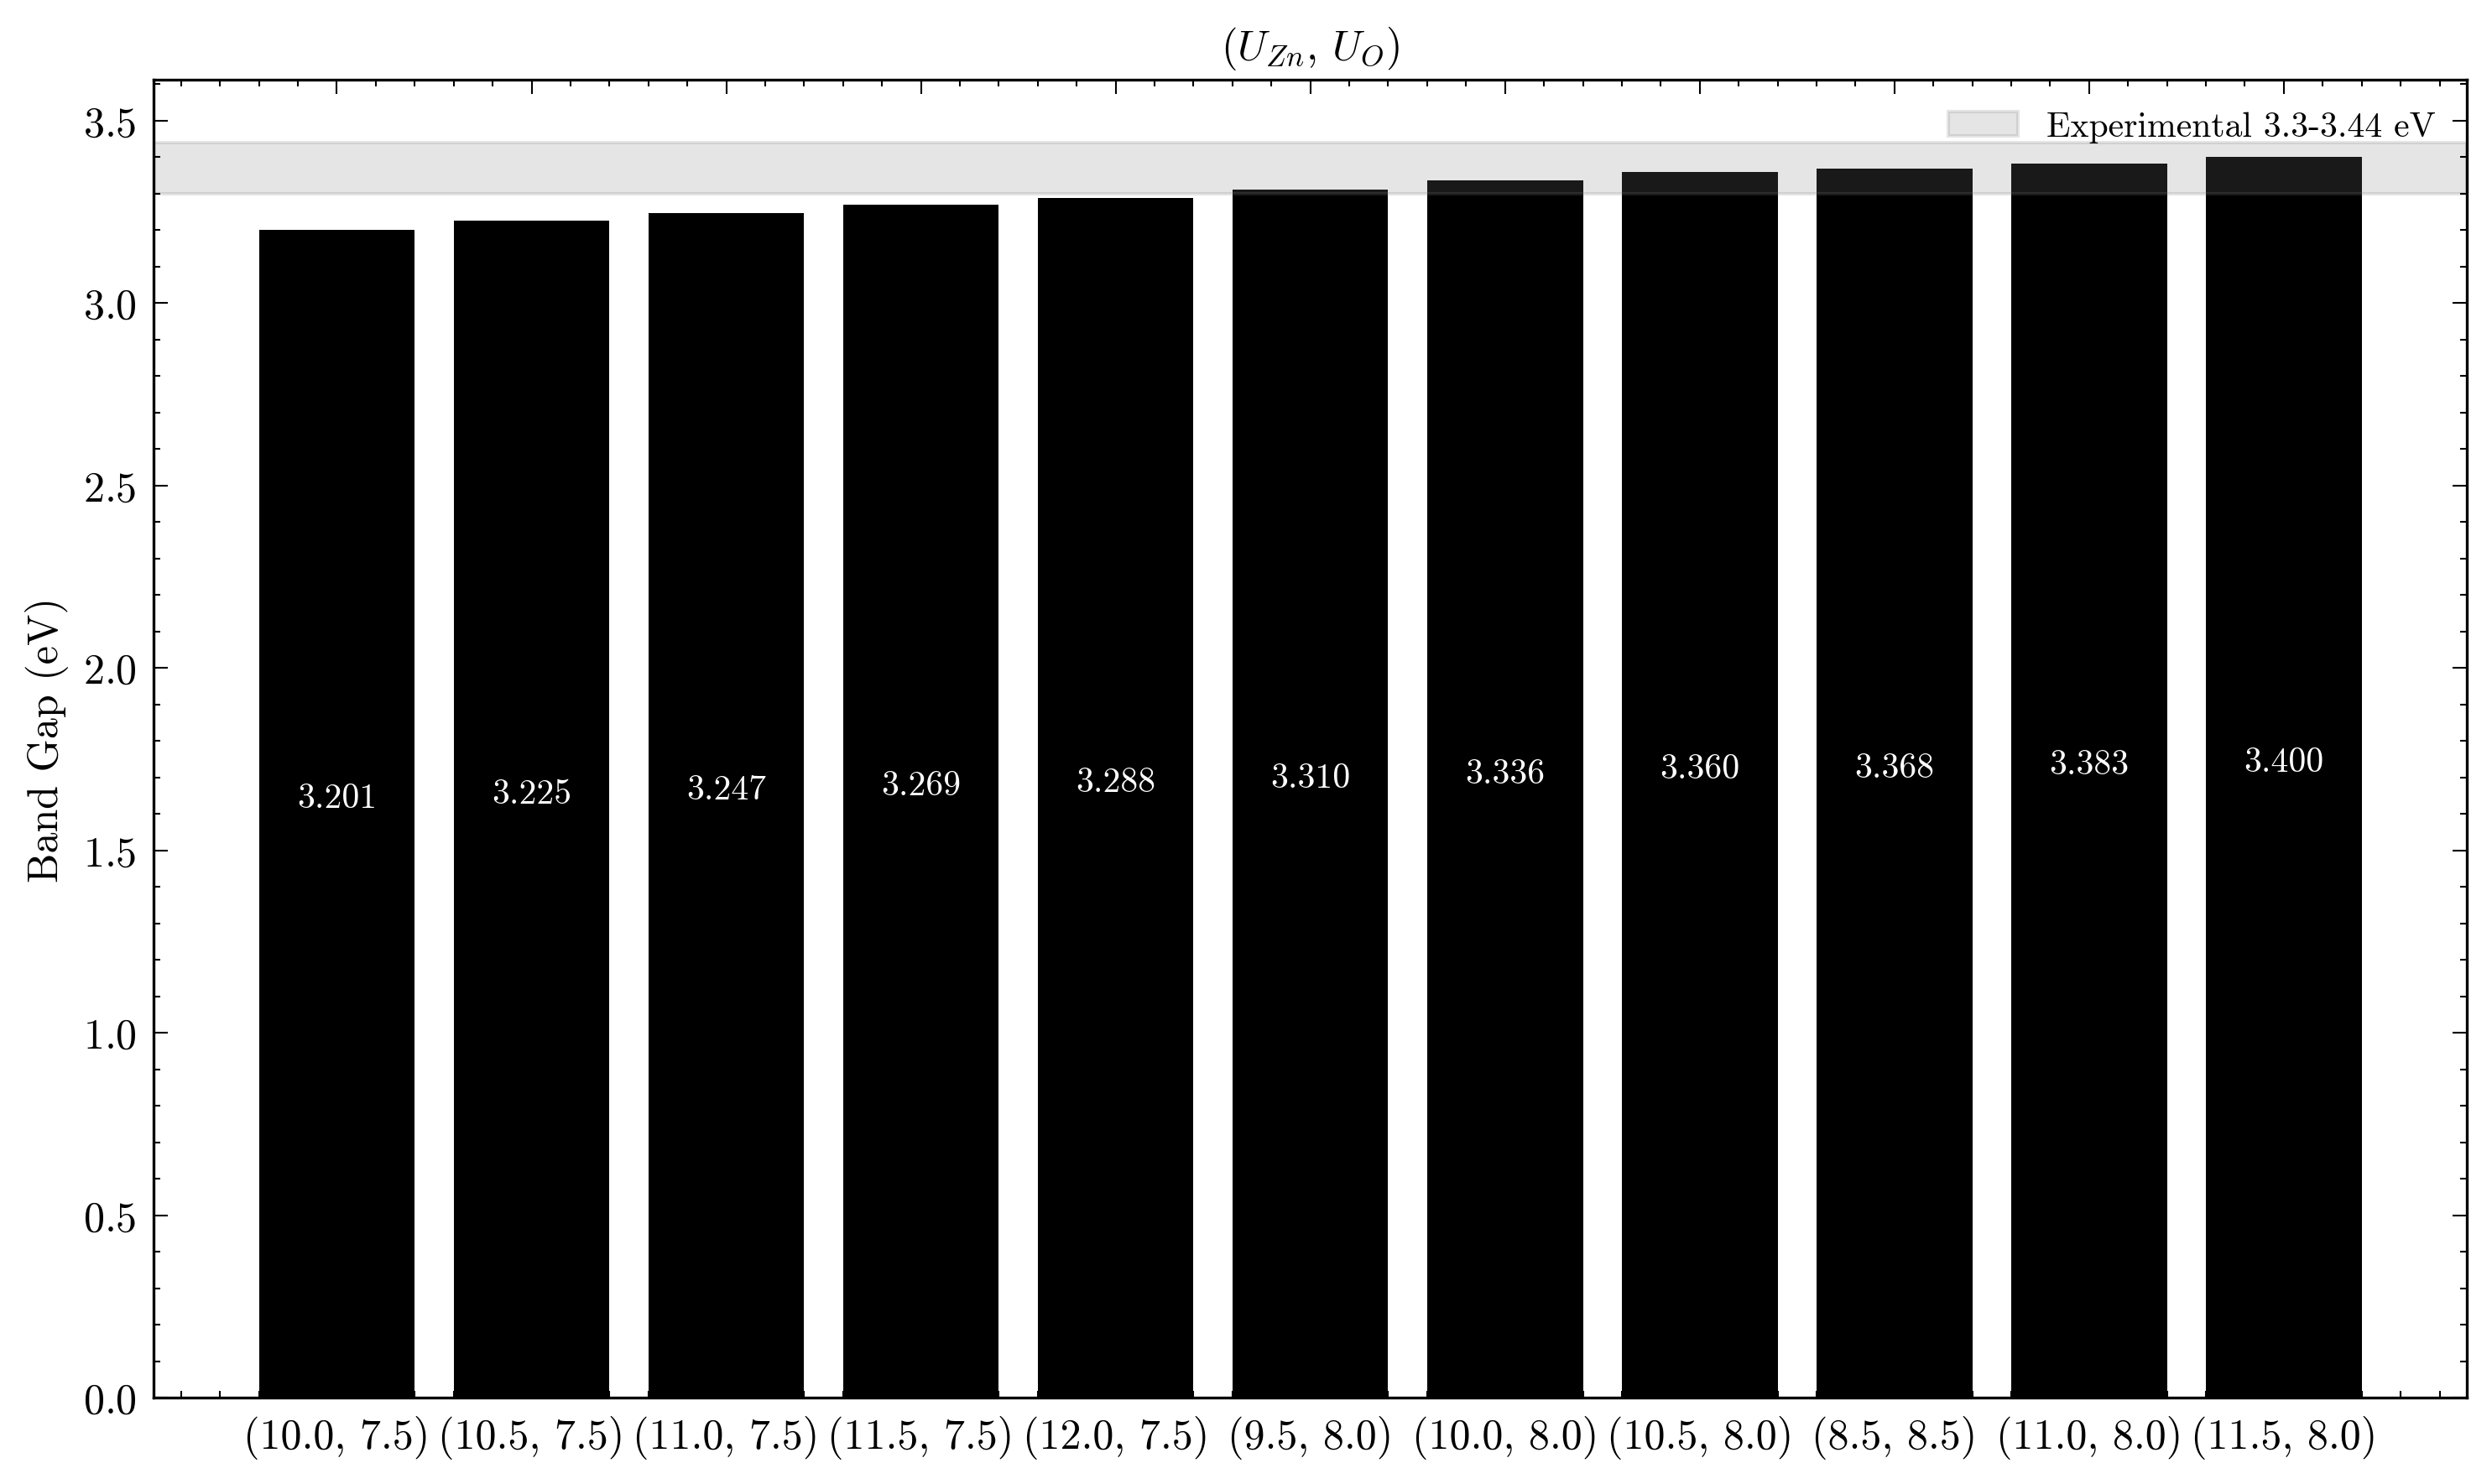

In [5]:
# Criar as labels combinando U_Zn e U_O
with plt.style.context('../../mpl_themes/computermodern.mplstyle'):
    df['Labels'] = df.apply(lambda row: f"({row['U_Zn']}, {row['U_O']})", axis=1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
    # fig.suptitle('Hubbard $U$ values of (Zn, O)')

    bars = ax.bar(df['Labels'], df['Band Gap (eV)'], color='k')

    # Inserir valores no centro das barras
    for bar, value in zip(bars, df['Band Gap (eV)']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value/2,
            f"{value:.3f}",
            ha='center', va='bottom',
            fontsize=10,
            color='white'
        )

    ax.set_ylabel('Band Gap (eV)')

    # Faixa experimental preenchida
    ax.axhspan(3.3, 3.44, color='gray', alpha=0.2, label='Experimental 3.3-3.44 eV')
    ax.set_title(r'($U_{Zn}$, $U_O$)')
    

    ax.legend()
    plt.tight_layout()
    plt.show()


---